# Training semantic segmentation (DeepLabv3+, PSPNet, or UnetPlusPlus) in Google Colab with CVAT masks and Azure Blob storage

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/datasantana/sam-image-processing/blob/main/notebooks/semantic_segmentation_training.ipynb)

In [1]:
# 🔧 Install Dependencies
# Run this cell first when opening the notebook in Google Colab

!pip install azure-storage-blob>=12.17.0
!pip install opencv-python>=4.8.0
!pip install pillow>=10.0.0
!pip install numpy>=1.24.0
!pip install matplotlib>=3.7.0

print("🎉 Dependencies installed successfully!")

🎉 Dependencies installed successfully!


# 🛰️ Semantic Segmentation Training Setup

This notebook initializes the connection to Azure Blob Storage, downloads drone imagery and labeled masks, and prepares reproducible training and validation datasets for semantic segmentation using DeepLabv3+, PSPNet, or UnetPlusPlus.

**Dataset structure:**
- Images: `assets/drone-imagery`
- Masks: `assets/pascual_annotation_masks/SegmentationClass`
- Label map: `assets/pascual_annotation_masks/labelmap.txt`

**Azure Blob Storage:**
- Container: `general-purpose`
- Connection string: stored securely in `AZURE_CONN_STR`

## 1: Azure Blob Connection & Download

In [2]:
# 📦 Connect to Azure Blob Storage and download images and masks
from azure.storage.blob import BlobServiceClient
from google.colab import userdata
import os

# 🔐 Azure Connection Configuration
# Option 1: Set as environment variable (recommended for Colab)
# import os
AZURE_CONN_STR = userdata.get('AZURE_CONNECTION_STRING')

# Option 2: Use getpass for secure input (uncomment to use)
# from getpass import getpass
# AZURE_CONN_STR = getpass('Enter Azure Connection String: ')

# Option 3: Set directly (replace with your actual connection string)
# AZURE_CONN_STR = "DefaultEndpointsProtocol=...<place complete string here>"

if AZURE_CONN_STR == "DefaultEndpointsProtocol=...<place complete string here>":
    print("⚠️  Please set your Azure connection string!")
    print("Uncomment one of the options above or set AZURE_CONN_STR variable")
    raise ValueError("Azure connection string not configured")

CONTAINER_NAME = "general-purpose"

# Blob Storage paths (where data is stored in Azure)
LOCAL_IMG_DIR = "assets/drone-imagery"
LOCAL_MASK_DIR = "assets/pascual_annotation_masks/SegmentationClass"
LOCAL_LABELMAP_DIR = "assets/pascual_annotation_masks"

# Local directories (where to download files)
LOCAL_DOWNLOAD_IMG_DIR = "assets/images"
LOCAL_DOWNLOAD_MASK_DIR = "assets/masks"

os.makedirs(LOCAL_DOWNLOAD_IMG_DIR, exist_ok=True)
os.makedirs(LOCAL_DOWNLOAD_MASK_DIR, exist_ok=True)

# Connect to blob container
try:
    blob_service_client = BlobServiceClient.from_connection_string(AZURE_CONN_STR)
    container_client = blob_service_client.get_container_client(CONTAINER_NAME)
    print("✅ Successfully connected to Azure Blob Storage")
except Exception as e:
    print(f"❌ Failed to connect to Azure Blob Storage: {e}")
    raise

def download_blobs(prefix, local_dir, file_types=None):
    """
    Download blobs with optional file type filtering

    Args:
        prefix: Blob prefix to search for
        local_dir: Local directory to download to
        file_types: List of extensions (case-insensitive) or None to download all files
                   e.g., ['.jpg', '.jpeg', '.png'] or None
    """
    print(f"🔍 Looking for blobs with prefix '{prefix}'...")
    if file_types:
        print(f"   File types: {file_types} (case-insensitive)")
    else:
        print("   Downloading all file types")

    try:
        blobs = list(container_client.list_blobs(name_starts_with=prefix))
        print(f"📁 Found {len(blobs)} total blobs with prefix '{prefix}'")

        downloaded_count = 0
        for blob in blobs:
            print(f"  - Checking blob: {blob.name}")

            # Check file type if specified
            should_download = True
            if file_types:
                should_download = any(blob.name.lower().endswith(ext.lower()) for ext in file_types)

            if should_download:
                local_path = os.path.join(local_dir, os.path.basename(blob.name))
                if not os.path.exists(local_path):
                    print(f"    ⬇️ Downloading {blob.name} -> {local_path}")
                    try:
                        with open(local_path, "wb") as f:
                            blob_data = container_client.download_blob(blob.name).readall()
                            f.write(blob_data)
                        downloaded_count += 1
                        print(f"    ✅ Downloaded {blob.name} ({len(blob_data)} bytes)")
                    except Exception as e:
                        print(f"    ❌ Failed to download {blob.name}: {e}")
                else:
                    print(f"    ⏭️ Skipping {blob.name} (already exists)")
            else:
                print(f"    ⏭️ Skipping {blob.name} (file type not in {file_types})")

        print(f"📊 Downloaded {downloaded_count} files from {prefix} to {local_dir}")

    except Exception as e:
        print(f"❌ Error listing blobs with prefix '{prefix}': {e}")

# Download images and masks with flexible file type matching
# Images: Support common image formats (case-insensitive)
download_blobs(LOCAL_IMG_DIR, LOCAL_DOWNLOAD_IMG_DIR, ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'])

# Masks: Support common mask formats (case-insensitive)
download_blobs(LOCAL_MASK_DIR, LOCAL_DOWNLOAD_MASK_DIR, ['.png', '.jpg', '.jpeg', '.bmp'])

✅ Successfully connected to Azure Blob Storage
🔍 Looking for blobs with prefix 'assets/drone-imagery'...
   File types: ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'] (case-insensitive)
📁 Found 66 total blobs with prefix 'assets/drone-imagery'
  - Checking blob: assets/drone-imagery/DJI_20250522111442_0006_D.JPG
    ⬇️ Downloading assets/drone-imagery/DJI_20250522111442_0006_D.JPG -> assets/images/DJI_20250522111442_0006_D.JPG
    ✅ Downloaded assets/drone-imagery/DJI_20250522111442_0006_D.JPG (7315456 bytes)
  - Checking blob: assets/drone-imagery/DJI_20250522111502_0016_D.JPG
    ⬇️ Downloading assets/drone-imagery/DJI_20250522111502_0016_D.JPG -> assets/images/DJI_20250522111502_0016_D.JPG
    ✅ Downloaded assets/drone-imagery/DJI_20250522111502_0016_D.JPG (7458816 bytes)
  - Checking blob: assets/drone-imagery/DJI_20250522111506_0018_D.JPG
    ⬇️ Downloading assets/drone-imagery/DJI_20250522111506_0018_D.JPG -> assets/images/DJI_20250522111506_0018_D.JPG
    ✅ Downloaded assets

## 2: 🧪 Dataset Preparation

This section reads and sorts the downloaded images and masks, then creates a reproducible split:
- First 53 images → Training set
- Remaining images → Validation set

Each image is matched with its corresponding mask by filename.

In [3]:
# List and sort all image and mask files (no format validation)
image_files = sorted([f for f in os.listdir(LOCAL_DOWNLOAD_IMG_DIR)])
mask_files = sorted([f for f in os.listdir(LOCAL_DOWNLOAD_MASK_DIR)])

print(f"📁 Found {len(image_files)} image files")
print(f"📁 Found {len(mask_files)} mask files")

# Match image-mask pairs by base filename (remove extensions)
def get_base_name(filename):
    return os.path.splitext(filename)[0]

# Create pairs based on matching base names
image_base_names = {get_base_name(f): f for f in image_files}
mask_base_names = {get_base_name(f): f for f in mask_files}

# Find matching pairs
matching_base_names = set(image_base_names.keys()) & set(mask_base_names.keys())
pairs = [(image_base_names[base], mask_base_names[base]) for base in sorted(matching_base_names)]

print(f"🔗 Found {len(pairs)} matching image-mask pairs")

# Reproducible split: first 53 for training
train_pairs = pairs[:53]
val_pairs = pairs[53:]

# Build full path dictionaries
def build_dataset(pairs, img_dir, mask_dir):
    return [
        {
            "img_path": os.path.join(img_dir, img),
            "seg_map_path": os.path.join(mask_dir, mask)
        }
        for img, mask in pairs
    ]

train_dataset = build_dataset(train_pairs, LOCAL_DOWNLOAD_IMG_DIR, LOCAL_DOWNLOAD_MASK_DIR)
val_dataset = build_dataset(val_pairs, LOCAL_DOWNLOAD_IMG_DIR, LOCAL_DOWNLOAD_MASK_DIR)

print(f"✅ Train set: {len(train_dataset)} images")
print(f"✅ Val set: {len(val_dataset)} images")
print(f"📁 Images directory: {LOCAL_DOWNLOAD_IMG_DIR}")
print(f"📁 Masks directory: {LOCAL_DOWNLOAD_MASK_DIR}")
print(f"🔗 Blob source - Images: {LOCAL_IMG_DIR}")
print(f"🔗 Blob source - Masks: {LOCAL_MASK_DIR}")

📁 Found 66 image files
📁 Found 66 mask files
🔗 Found 66 matching image-mask pairs
✅ Train set: 53 images
✅ Val set: 13 images
📁 Images directory: assets/images
📁 Masks directory: assets/masks
🔗 Blob source - Images: assets/drone-imagery
🔗 Blob source - Masks: assets/pascual_annotation_masks/SegmentationClass


## 3: 🚀 Model Training Setup

Now we'll set up the semantic segmentation training pipeline with support for:
- **DeepLabv3+** with ResNet/EfficientNet backbone
- **PSPNet** with ResNet/EfficientNet backbone  
- **UnetPlusPlus** with ResNet/EfficientNet backbone
- Easy model switching
- Enhanced data augmentation and regularization
- Configurable training parameters
- Label map integration

### 3.1: 🔧 Deep Learning Environment Setup

In [4]:
# 🔧 Install Deep Learning Dependencies
# PyTorch and related packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install segmentation-models-pytorch>=0.3.3
!pip install albumentations>=1.3.0
!pip install timm>=0.9.0

# Additional ML utilities
!pip install scikit-learn>=1.3.0
!pip install tqdm>=4.65.0
!pip install tensorboard>=2.13.0

print("🎉 Deep learning environment setup complete!")

Looking in indexes: https://download.pytorch.org/whl/cu118
🎉 Deep learning environment setup complete!


### 3.2: 📋 Model Configuration

In [5]:
# 📋 Model and Training Configuration
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 🎯 Model Selection - Change this to switch models
MODEL_ARCH = "UnetPlusPlus"  # Options: "DeepLabv3+", "PSPNet", "UnetPlusPlus"
BACKBONE = "resnet50"      # Options: "resnet18", "resnet34", "resnet50", "resnet101", "resnet152", "efficientnet-b4"

# 🏋️ Training Configuration - Optimized for Better Performance
BATCH_SIZE = 6          # Smaller batch for better generalization
LEARNING_RATE = 5e-5    # Lower learning rate for stability
NUM_EPOCHS = 80         # More epochs for convergence
IMAGE_SIZE = 512        # Keep 512 for memory efficiency (can try 768 if GPU allows)
NUM_WORKERS = 2

# 📊 Model Architecture Settings
if MODEL_ARCH == "DeepLabv3+":
    print(f"🎯 Using DeepLabv3+ with {BACKBONE} backbone")
    model_class = smp.DeepLabV3Plus
elif MODEL_ARCH == "PSPNet":
    print(f"🎯 Using PSPNet with {BACKBONE} backbone")
    model_class = smp.PSPNet
elif MODEL_ARCH == "UnetPlusPlus":
    print(f"🎯 Using UnetPlusPlus with {BACKBONE} backbone")
    model_class = smp.UnetPlusPlus
else:
    raise ValueError(f"Unsupported model architecture: {MODEL_ARCH}. Options: DeepLabv3+, PSPNet, UnetPlusPlus")

# 🖥️ Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# 📁 Output Configuration
MODEL_SAVE_DIR = "models"
LOGS_DIR = "logs"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

print(f"✅ Configuration complete!")
print(f"   Model: {MODEL_ARCH}")
print(f"   Backbone: {BACKBONE}")
print(f"   Batch Size: {BATCH_SIZE}")

print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")

🎯 Using UnetPlusPlus with resnet50 backbone
🖥️ Using device: cuda
✅ Configuration complete!
   Model: UnetPlusPlus
   Backbone: resnet50
   Batch Size: 6
   Learning Rate: 5e-05
   Epochs: 80
   Image Size: 512x512


### 3.3: 🏷️ Class Labels and Label Map

In [6]:
# 🏷️ Load and Process Label Map
import numpy as np
from PIL import Image
import json
import cv2

# Local path where labelmap will be downloaded
local_labelmap_path = "assets/labelmap.txt"

try:
    # Try to download labelmap from blob storage
    print("🔍 Looking for labelmap in blob storage...")
    labelmap_blobs = list(container_client.list_blobs(name_starts_with=LOCAL_LABELMAP_DIR))

    labelmap_found = False
    for blob in labelmap_blobs:
        if 'labelmap' in blob.name.lower() and blob.name.endswith('.txt'):
            print(f"📥 Downloading labelmap: {blob.name} -> {local_labelmap_path}")
            with open(local_labelmap_path, "wb") as f:
                f.write(container_client.download_blob(blob.name).readall())
            labelmap_found = True
            break

    if not labelmap_found:
        raise FileNotFoundError("No labelmap.txt file found in blob storage")

    # Load labelmap from downloaded file
    if os.path.exists(local_labelmap_path):
        with open(local_labelmap_path, 'r') as f:
            class_names = [line.strip() for line in f.readlines() if line.strip()]
        print(f"✅ Loaded {len(class_names)} classes from labelmap")
    else:
        raise FileNotFoundError("Labelmap download failed")

except Exception as e:
    print(f"⚠️ Could not load labelmap: {e}")
    print("🔧 Creating default labelmap by analyzing mask files...")

    # Check if mask variables are available
    if 'LOCAL_DOWNLOAD_MASK_DIR' in locals() and 'mask_files' in locals():
        # Analyze a few mask files to determine unique classes
        sample_masks = mask_files[:min(10, len(mask_files))]
        unique_values = set()

        for mask_file in sample_masks:
            mask_path = os.path.join(LOCAL_DOWNLOAD_MASK_DIR, mask_file)
            try:
                mask = np.array(Image.open(mask_path))
                unique_values.update(np.unique(mask))
            except Exception as mask_error:
                print(f"⚠️ Could not read mask {mask_file}: {mask_error}")

        # Create class names
        unique_values = sorted(list(unique_values))
        class_names = [f"class_{i}" for i in unique_values]
        print(f"🔍 Found {len(unique_values)} unique classes: {unique_values}")
    else:
        print("⚠️ Mask files not available. Creating minimal class set.")
        class_names = ['background', 'foreground']

# Set up classes
NUM_CLASSES = len(class_names)
print(f"📊 Number of classes: {NUM_CLASSES}")
print(f"🏷️ Class names: {class_names}")

# Create class to index mapping
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for idx, name in enumerate(class_names)}

# 🎨 RGB Mask Detection and Processing
print("\n🔍 Analyzing mask format...")

# Initialize RGB to class mapping
rgb_to_class = None

# Check if mask data is available for RGB analysis
if 'LOCAL_DOWNLOAD_MASK_DIR' in locals() and 'mask_files' in locals() and len(mask_files) > 0:
    # Check if masks are RGB or grayscale by examining a sample
    sample_mask_path = os.path.join(LOCAL_DOWNLOAD_MASK_DIR, mask_files[0])

    try:
        sample_mask = cv2.imread(sample_mask_path)
        sample_mask_gray = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

        # Detect if mask is RGB (color) or grayscale
        is_rgb_mask = False
        if sample_mask is not None and len(sample_mask.shape) == 3:
            # Check if all channels are different (RGB) or same (grayscale saved as 3-channel)
            if not np.array_equal(sample_mask[:,:,0], sample_mask[:,:,1]) or not np.array_equal(sample_mask[:,:,1], sample_mask[:,:,2]):
                is_rgb_mask = True

        print(f"🎨 Mask format detected: {'RGB Color' if is_rgb_mask else 'Grayscale'}")

        if is_rgb_mask:
            print("🎨 Processing RGB masks...")

            # Try to parse RGB values from labelmap if available
            if os.path.exists(local_labelmap_path):
                print("📋 Parsing RGB values from labelmap...")
                rgb_to_class = {}

                try:
                    with open(local_labelmap_path, 'r') as f:
                        lines = f.readlines()

                    for idx, line in enumerate(lines):
                        line = line.strip()
                        if ':' in line and ',' in line:
                            # Format: "ClassName:R,G,B"
                            parts = line.split(':')
                            if len(parts) >= 2:
                                class_name = parts[0].strip()
                                rgb_str = parts[1].strip()
                                try:
                                    r, g, b = map(int, rgb_str.split(','))
                                    # Convert RGB to BGR for OpenCV compatibility
                                    bgr_color = (b, g, r)
                                    rgb_to_class[bgr_color] = idx
                                    print(f"   {class_name}: RGB({r},{g},{b}) -> BGR{bgr_color} -> Class {idx}")
                                except ValueError as ve:
                                    print(f"   ⚠️ Could not parse RGB values for: {line} - {ve}")

                    print(f"✅ Created RGB-to-class mapping with {len(rgb_to_class)} colors")

                except Exception as e:
                    print(f"⚠️ Error parsing RGB labelmap: {e}")
                    rgb_to_class = None

            if rgb_to_class is None or len(rgb_to_class) == 0:
                print("🔍 Analyzing RGB colors in masks...")
                # Analyze actual mask files to build color mapping
                unique_colors = set()

                for mask_file in mask_files[:min(5, len(mask_files))]:
                    mask_path = os.path.join(LOCAL_DOWNLOAD_MASK_DIR, mask_file)
                    try:
                        mask = cv2.imread(mask_path)
                        if mask is not None:
                            # Get unique BGR colors
                            reshaped = mask.reshape(-1, 3)
                            unique_colors.update([tuple(color) for color in reshaped])
                    except Exception as e:
                        print(f"   ⚠️ Could not analyze {mask_file}: {e}")

                # Create mapping from unique colors to class indices
                unique_colors = sorted(list(unique_colors))[:NUM_CLASSES]  # Limit to expected number of classes
                rgb_to_class = {color: idx for idx, color in enumerate(unique_colors)}

                print(f"🎨 Found {len(unique_colors)} unique colors in masks:")
                for color, idx in list(rgb_to_class.items())[:5]:
                    print(f"   BGR{color} -> Class {idx}")
                if len(rgb_to_class) > 5:
                    print(f"   ... and {len(rgb_to_class) - 5} more")
        else:
            print("📊 Masks are grayscale - no RGB mapping needed")

    except Exception as e:
        print(f"⚠️ Error analyzing mask format: {e}")
        print("📊 Defaulting to grayscale mode")

else:
    print("⚠️ Mask files not available for RGB analysis")
    print("📊 Run the data download cell first, then re-run this cell")

print(f"\n✅ Label mapping complete!")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Mapping: {dict(list(class_to_idx.items())[:5])}{'...' if len(class_to_idx) > 5 else ''}")
print(f"   RGB Support: {'Enabled' if rgb_to_class and len(rgb_to_class) > 0 else 'Disabled'}")
print(f"🔗 Blob source - Labelmap: {LOCAL_LABELMAP_DIR}")
print(f"📁 Local labelmap: {local_labelmap_path if os.path.exists(local_labelmap_path) else 'Generated from masks'}")

# Debug info
if rgb_to_class:
    print(f"🎨 RGB mapping contains {len(rgb_to_class)} color mappings")
    sample_colors = list(rgb_to_class.items())[:3]
    for color, class_idx in sample_colors:
        print(f"   Color {color} -> Class {class_idx}")
else:
    print("🎨 No RGB mapping created - check that masks are RGB and data is downloaded")

🔍 Looking for labelmap in blob storage...
📥 Downloading labelmap: assets/pascual_annotation_masks/labelmap.txt -> assets/labelmap.txt
✅ Loaded 14 classes from labelmap
📊 Number of classes: 14
🏷️ Class names: ['# label:color_rgb:parts:actions', 'Brownfields:178,80,80::', 'Buildings:250,50,83::', 'Fence:184,61,245::', 'Ground Surface:255,204,51::', 'Lightning Posts:245,147,49::', 'Parkinglots:140,120,240::', 'Paved Surface:52,209,183::', 'Pools:51,221,255::', 'Road Surface:89,134,179::', 'Sports Fields:250,250,55::', 'Vegetation:36,179,83::', 'Vehicle:204,51,102::', 'background:0,0,0::']

🔍 Analyzing mask format...
🎨 Mask format detected: RGB Color
🎨 Processing RGB masks...
📋 Parsing RGB values from labelmap...
   Brownfields: RGB(178,80,80) -> BGR(80, 80, 178) -> Class 1
   Buildings: RGB(250,50,83) -> BGR(83, 50, 250) -> Class 2
   Fence: RGB(184,61,245) -> BGR(245, 61, 184) -> Class 3
   Ground Surface: RGB(255,204,51) -> BGR(51, 204, 255) -> Class 4
   Lightning Posts: RGB(245,147,49

### 3.4: 🔄 Data Transforms and Dataset

In [7]:
# 🔄 RGB-Aware Dataset and Transforms
from torch.utils.data import Dataset
import cv2

class RGBSegmentationDataset(Dataset):
    def __init__(self, dataset, transforms=None, rgb_to_class=None, use_rgb=False):
        self.dataset = dataset
        self.transforms = transforms
        self.rgb_to_class = rgb_to_class
        self.use_rgb = use_rgb

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # Load image
        image = cv2.imread(item['img_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.use_rgb and self.rgb_to_class is not None:
            # Load mask as RGB and convert to class indices
            mask_rgb = cv2.imread(item['seg_map_path'], cv2.IMREAD_COLOR)
            mask = self.rgb_to_class_indices(mask_rgb)
        else:
            # Load mask as grayscale (fallback)
            mask = cv2.imread(item['seg_map_path'], cv2.IMREAD_GRAYSCALE)

        # Apply transforms
        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask.long()

    def rgb_to_class_indices(self, rgb_mask):
        """Convert RGB mask to class indices"""
        height, width, _ = rgb_mask.shape
        class_mask = np.zeros((height, width), dtype=np.uint8)

        for y in range(height):
            for x in range(width):
                pixel_bgr = tuple(rgb_mask[y, x])

                if pixel_bgr in self.rgb_to_class:
                    class_mask[y, x] = self.rgb_to_class[pixel_bgr]
                else:
                    # Find closest color if exact match not found
                    min_distance = float('inf')
                    closest_class = 0

                    for color, class_idx in self.rgb_to_class.items():
                        distance = np.sqrt(sum((pixel_bgr[i] - color[i])**2 for i in range(3)))
                        if distance < min_distance:
                            min_distance = distance
                            closest_class = class_idx

                    class_mask[y, x] = closest_class

        return class_mask

# 🎨 Define Transforms - Enhanced for Better Generalization
train_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    # Geometric augmentations (prevent spatial overfitting)
    A.HorizontalFlip(p=0.7),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.7),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.6),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),

    # Color augmentations (prevent color bias overfitting)
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),

    # Noise and blur (improve robustness)
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.MotionBlur(blur_limit=7, p=0.2),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 📊 Create Datasets with RGB Support
print("🔄 Creating datasets...")

# Check if we have RGB mask support (safely check for rgb_to_class)
try:
    use_rgb_masks = rgb_to_class is not None and len(rgb_to_class) > 0
except NameError:
    use_rgb_masks = False
    rgb_to_class = None

if use_rgb_masks:
    print("🎨 Using RGB mask support...")
    train_ds = RGBSegmentationDataset(train_dataset, transforms=train_transforms,
                                     rgb_to_class=rgb_to_class, use_rgb=True)
    val_ds = RGBSegmentationDataset(val_dataset, transforms=val_transforms,
                                   rgb_to_class=rgb_to_class, use_rgb=True)
else:
    print("📊 Using grayscale mask fallback...")
    train_ds = RGBSegmentationDataset(train_dataset, transforms=train_transforms,
                                     rgb_to_class=None, use_rgb=False)
    val_ds = RGBSegmentationDataset(val_dataset, transforms=val_transforms,
                                   rgb_to_class=None, use_rgb=False)

# 🔄 Create DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Datasets created successfully!")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Samples per batch: {BATCH_SIZE}")
print(f"   RGB mask support: {'Enabled' if use_rgb_masks else 'Disabled'}")

# 🧪 Test data loading
try:
    sample_image, sample_mask = next(iter(train_loader))
    print(f"📊 Data loading test successful!")
    print(f"   Image shape: {sample_image.shape}")
    print(f"   Mask shape: {sample_mask.shape}")
    print(f"   Image range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
    print(f"   Mask classes: {torch.unique(sample_mask)}")
    print(f"   Mask range: [{sample_mask.min()}, {sample_mask.max()}]")

    # Validate mask values are in correct range
    if sample_mask.max() < NUM_CLASSES and sample_mask.min() >= 0:
        print(f"✅ Mask values in valid range [0, {NUM_CLASSES-1}]")
    else:
        print(f"❌ Invalid mask values! Range: [{sample_mask.min()}, {sample_mask.max()}], Expected: [0, {NUM_CLASSES-1}]")

except Exception as e:
    print(f"❌ Data loading test failed: {e}")

🔄 Creating datasets...
🎨 Using RGB mask support...
✅ Datasets created successfully!
   Training batches: 9
   Validation batches: 3
   Samples per batch: 6
   RGB mask support: Enabled


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-3666318608.py:73: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
/tmp/ipython-input-3666318608.py:83: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


📊 Data loading test successful!
   Image shape: torch.Size([6, 3, 512, 512])
   Mask shape: torch.Size([6, 512, 512])
   Image range: [-2.118, 2.640]
   Mask classes: tensor([ 0,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
   Mask range: [0, 13]
✅ Mask values in valid range [0, 13]


### 3.5: 🏗️ Model Initialization

This cell creates the PyTorch model and sets up training components:

- **Model Creation**: DeepLabv3+ or PSPNet with ResNet backbone
- **Loss Function**: DiceLoss for multiclass segmentation  
- **Optimizer**: Adam with weight decay
- **Scheduler**: ReduceLROnPlateau for adaptive learning rate

In [8]:
# 🏗️ Model Initialization
print("🏗️ Initializing model...")

# Create the model with regularization
print(f"🎯 Creating {MODEL_ARCH} with {BACKBONE} backbone...")

# Model creation with dropout for regularization
if MODEL_ARCH in ["DeepLabv3+", "PSPNet"]:
    model = model_class(
        encoder_name=BACKBONE,
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
    )
elif MODEL_ARCH == "UnetPlusPlus":
    model = model_class(
        encoder_name=BACKBONE,
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
        decoder_use_batchnorm=True,
        decoder_dropout=0.2,  # Add dropout for regularization
    )

print(f"   Regularization: {'Dropout 0.2' if MODEL_ARCH == 'UnetPlusPlus' else 'BatchNorm + Weight Decay'}")

# Move model to device
model = model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model created successfully!")
print(f"   Architecture: {MODEL_ARCH}")
print(f"   Backbone: {BACKBONE}")
print(f"   Input channels: 3")
print(f"   Output classes: {NUM_CLASSES}")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Device: {device}")

# 🎯 Loss Function and Optimizer Setup
print("\n⚖️ Setting up loss function and optimizer...")

# Combined Loss Function - Dice + Focal for better performance
dice_loss = smp.losses.DiceLoss(mode='multiclass')
focal_loss = smp.losses.FocalLoss(mode='multiclass', alpha=0.25, gamma=2.0)

def combined_loss(pred, target):
    """Combine Dice and Focal losses for better segmentation performance"""
    return 0.6 * dice_loss(pred, target) + 0.4 * focal_loss(pred, target)

criterion = combined_loss
print(f"   Loss function: Combined (60% Dice + 40% Focal)")

# Optimizer - Adam with enhanced weight decay for regularization
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

# Learning rate scheduler - more conservative for stability
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=8  # More patience, gentler reduction
)

print(f"✅ Enhanced training setup complete!")
print(f"   Optimizer: Adam (lr={LEARNING_RATE})")
print(f"   Scheduler: ReduceLROnPlateau (factor=0.7, patience=8)")
print(f"   Weight decay: 1e-3 (increased for regularization)")
print(f"   Regularization: Enhanced augmentation + {'Dropout' if MODEL_ARCH == 'UnetPlusPlus' else 'Weight decay'}")

🏗️ Initializing model...
🎯 Creating UnetPlusPlus with resnet50 backbone...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

   Regularization: Dropout 0.2
✅ Model created successfully!
   Architecture: UnetPlusPlus
   Backbone: resnet50
   Input channels: 3
   Output classes: 14
   Total parameters: 48,987,630
   Trainable parameters: 48,987,630
   Device: cuda

⚖️ Setting up loss function and optimizer...
   Loss function: Combined (60% Dice + 40% Focal)
✅ Enhanced training setup complete!
   Optimizer: Adam (lr=5e-05)
   Scheduler: ReduceLROnPlateau (factor=0.7, patience=8)
   Weight decay: 1e-3 (increased for regularization)
   Regularization: Enhanced augmentation + Dropout


### 3.6: 🧪 Forward Pass Test

**What is a Forward Pass Test?**
- Tests that the model can process data without errors
- Verifies input/output shapes are correct (e.g., [batch, 3, 512, 512] → [batch, 14, 512, 512])
- Catches issues like BatchNorm errors before training starts
- Uses `model.eval()` mode to avoid BatchNorm issues with batch size = 1

**Why is it needed?**
- Saves time by catching configuration errors early
- Validates that NUM_CLASSES matches model output
- Ensures GPU memory is sufficient for the model
- Prevents crashes during actual training

In [9]:
# 🧪 Fixed Forward Pass Test
# The BatchNorm error occurs because the model is in training mode with batch_size=1
# Solution: Set model to eval() mode for testing

print("🧪 Testing model forward pass...")

try:
    # Set model to evaluation mode to avoid BatchNorm issues
    model.eval()

    with torch.no_grad():
        # Test with different batch sizes
        test_batch_sizes = [1, 2]

        for batch_size in test_batch_sizes:
            dummy_input = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
            dummy_output = model(dummy_input)

            print(f"✅ Batch size {batch_size} test successful!")
            print(f"   Input shape: {dummy_input.shape}")
            print(f"   Output shape: {dummy_output.shape}")
            print(f"   Output classes: {dummy_output.shape[1]} (expected: {NUM_CLASSES})")

    # Set back to training mode for actual training
    model.train()
    print(f"🔄 Model set back to training mode")

except Exception as e:
    print(f"❌ Forward pass test failed: {e}")
    print("💡 This might indicate a model architecture issue")

print(f"\n🎯 Model is ready for training!")
print(f"   Architecture: {MODEL_ARCH}")
print(f"   Backbone: {BACKBONE}")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

🧪 Testing model forward pass...
✅ Batch size 1 test successful!
   Input shape: torch.Size([1, 3, 512, 512])
   Output shape: torch.Size([1, 14, 512, 512])
   Output classes: 14 (expected: 14)
✅ Batch size 2 test successful!
   Input shape: torch.Size([2, 3, 512, 512])
   Output shape: torch.Size([2, 14, 512, 512])
   Output classes: 14 (expected: 14)
🔄 Model set back to training mode

🎯 Model is ready for training!
   Architecture: UnetPlusPlus
   Backbone: resnet50
   Classes: 14
   Parameters: 48,987,630


## 4: 🚀 Training Loop

**Current Status**: We have a **READY-TO-TRAIN** model, not a trained one yet!

So far we've only:
- ✅ Downloaded data from Azure Blob Storage
- ✅ Prepared datasets and data loaders  
- ✅ Initialized the model architecture
- ✅ Set up loss function, optimizer, and scheduler

**Next**: Run the actual training to get a **TRAINED** model!

In [10]:
# Add this at the very beginning of the training loop cell:

import time
from tqdm import tqdm

# Define training and validation functions
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """Train the model for one epoch"""
    model.train()
    running_loss = 0.0
    running_iou = 0.0

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")

    for batch_idx, (images, masks) in enumerate(progress_bar):
        images = images.to(device)
        masks = masks.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Calculate IoU
        with torch.no_grad():
            predicted = torch.argmax(outputs, dim=1)
            iou = calculate_iou(predicted, masks)

        running_loss += loss.item()
        running_iou += iou

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'IoU': f'{iou:.4f}'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_iou = running_iou / len(train_loader)

    return epoch_loss, epoch_iou

def validate_one_epoch(model, val_loader, criterion, device):
    """Validate the model for one epoch"""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0

    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validation")

        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Calculate IoU
            predicted = torch.argmax(outputs, dim=1)
            iou = calculate_iou(predicted, masks)

            running_loss += loss.item()
            running_iou += iou

            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'IoU': f'{iou:.4f}'
            })

    epoch_loss = running_loss / len(val_loader)
    epoch_iou = running_iou / len(val_loader)

    return epoch_loss, epoch_iou

def calculate_iou(predicted, target):
    """Calculate Intersection over Union (IoU) for segmentation"""
    intersection = torch.logical_and(predicted == target, target != 0).sum().float()
    union = torch.logical_or(predicted != 0, target != 0).sum().float()

    if union == 0:
        return 1.0  # Perfect score if both are empty

    iou = intersection / union
    return iou.item()

# 🏃‍♂️ ACTUAL TRAINING LOOP - This creates the TRAINED model!
print("🚀 Starting training...")
print(f"   Model: {MODEL_ARCH} with {BACKBONE} backbone")
print(f"   Dataset: {len(train_dataset)} train, {len(val_dataset)} val samples")
print(f"   Training for {NUM_EPOCHS} epochs")
print("="*60)

# Training history
train_losses = []
train_ious = []
val_losses = []
val_ious = []
best_val_iou = 0.0

# Start training
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n📅 Epoch {epoch+1}/{NUM_EPOCHS}")

    # Train
    train_loss, train_iou = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )

    # Validate
    val_loss, val_iou = validate_one_epoch(
        model, val_loader, criterion, device
    )

    # Update learning rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Save metrics
    train_losses.append(train_loss)
    train_ious.append(train_iou)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    # Print epoch summary
    print(f"📊 Epoch {epoch+1} Results:")
    print(f"   Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"   Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
    print(f"   Learning Rate: {current_lr:.2e}")

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_model_path = f"{MODEL_SAVE_DIR}/best_{MODEL_ARCH}_{BACKBONE}_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_iou': val_iou,
            'model_arch': MODEL_ARCH,
            'backbone': BACKBONE,
            'num_classes': NUM_CLASSES,
            'class_names': class_names
        }, best_model_path)
        print(f"💾 New best model saved! IoU: {val_iou:.4f}")

# Training completed
end_time = time.time()
training_time = end_time - start_time

print("="*60)
print("🎉 TRAINING COMPLETED!")
print(f"⏱️ Total training time: {training_time/3600:.2f} hours")
print(f"🏆 Best validation IoU: {best_val_iou:.4f}")
print(f"💾 Best model saved to: {best_model_path}")
print(f"📊 Training history: {len(train_losses)} epochs")

# Final model save
final_model_path = f"{MODEL_SAVE_DIR}/final_{MODEL_ARCH}_{BACKBONE}.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'training_history': {
        'train_losses': train_losses,
        'train_ious': train_ious,
        'val_losses': val_losses,
        'val_ious': val_ious
    },
    'model_arch': MODEL_ARCH,
    'backbone': BACKBONE,
    'num_classes': NUM_CLASSES,
    'class_names': class_names
}, final_model_path)

print(f"💾 Final model saved to: {final_model_path}")
print("\n🎯 YOU NOW HAVE A TRAINED MODEL! 🎯")

🚀 Starting training...
   Model: UnetPlusPlus with resnet50 backbone
   Dataset: 53 train, 13 val samples
   Training for 80 epochs

📅 Epoch 1/80


Validation: 100%|██████████| 3/3 [01:54<00:00, 38.30s/it, Loss=1.1356, IoU=0.0523]


📊 Epoch 1 Results:
   Train Loss: 1.8049 | Train IoU: 0.1242
   Val Loss: 1.2465 | Val IoU: 0.0499
   Learning Rate: 5.00e-05
💾 New best model saved! IoU: 0.0499

📅 Epoch 2/80


Validation: 100%|██████████| 3/3 [01:55<00:00, 38.58s/it, Loss=1.1298, IoU=0.1315]


📊 Epoch 2 Results:
   Train Loss: 1.5321 | Train IoU: 0.1761
   Val Loss: 1.2382 | Val IoU: 0.1250
   Learning Rate: 5.00e-05
💾 New best model saved! IoU: 0.1250

📅 Epoch 3/80


...

📊 Epoch 78 Results:
   Train Loss: 0.5950 | Train IoU: 0.5938
   Val Loss: 0.5261 | Val IoU: 0.6001
   Learning Rate: 5.00e-05

📅 Epoch 79/80


Validation: 100%|██████████| 3/3 [01:59<00:00, 39.75s/it, Loss=0.4052, IoU=0.5899]


📊 Epoch 79 Results:
   Train Loss: 0.6078 | Train IoU: 0.5884
   Val Loss: 0.5184 | Val IoU: 0.5945
   Learning Rate: 5.00e-05

📅 Epoch 80/80


Validation: 100%|██████████| 3/3 [01:59<00:00, 40.00s/it, Loss=0.4110, IoU=0.6173]


📊 Epoch 80 Results:
   Train Loss: 0.5974 | Train IoU: 0.5989
   Val Loss: 0.5185 | Val IoU: 0.6200
   Learning Rate: 5.00e-05
💾 New best model saved! IoU: 0.6200
🎉 TRAINING COMPLETED!
⏱️ Total training time: 13.23 hours
🏆 Best validation IoU: 0.6200
💾 Best model saved to: models/best_UnetPlusPlus_resnet50_epoch_80.pth
📊 Training history: 80 epochs
💾 Final model saved to: models/final_UnetPlusPlus_resnet50.pth

🎯 YOU NOW HAVE A TRAINED MODEL! 🎯


### 4.3: 📈 Training Results Visualization

/tmp/ipython-input-989803271.py:58: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-989803271.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-989803271.py:58: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-989803271.py:58: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-989803271.py:58: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-989803271.py:58: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-989803271.py:59: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'{LOGS_DIR}/training_re

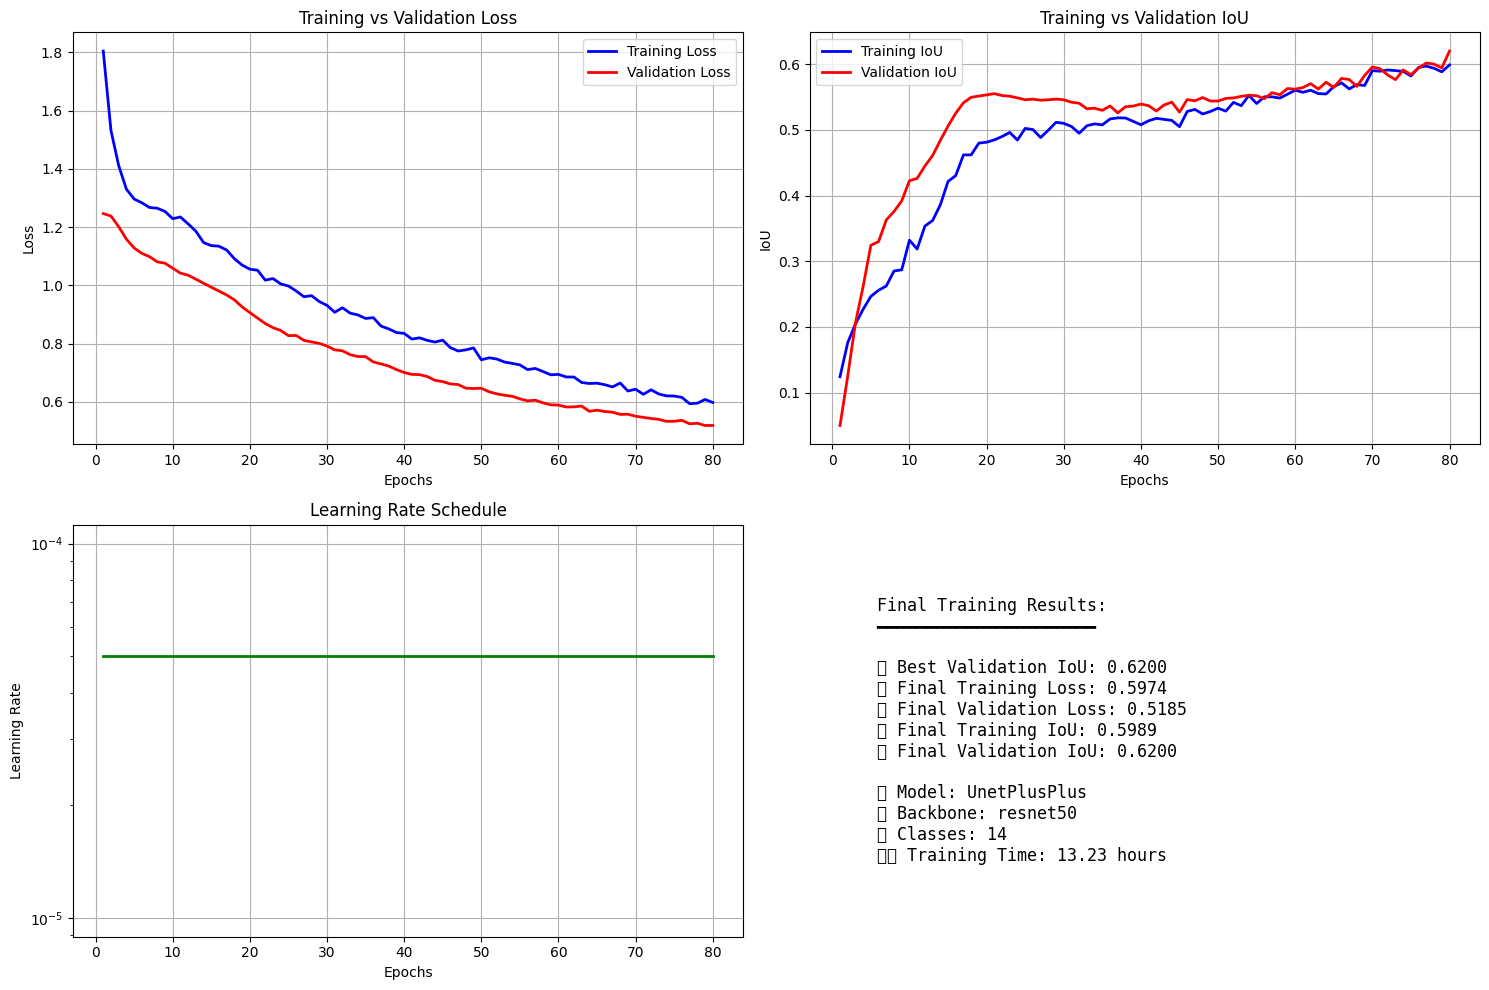

✅ Training visualization complete!
📊 Plot saved to: logs/training_results.png

🎯 TRAINING SUMMARY
✅ Status: TRAINED MODEL READY!
🏗️ Architecture: UnetPlusPlus with resnet50
📊 Classes: 14
🏆 Best IoU: 0.6200
💾 Best model: models/best_UnetPlusPlus_resnet50_epoch_80.pth
💾 Final model: models/final_UnetPlusPlus_resnet50.pth


In [11]:
# 📈 Plot Training Results
import matplotlib.pyplot as plt

# Create training plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Loss plots
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# IoU plots
ax2.plot(epochs, train_ious, 'b-', label='Training IoU', linewidth=2)
ax2.plot(epochs, val_ious, 'r-', label='Validation IoU', linewidth=2)
ax2.set_title('Training vs Validation IoU')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('IoU')
ax2.legend()
ax2.grid(True)

# Learning rate plot
ax3.plot(epochs, [optimizer.param_groups[0]['lr']] * len(epochs), 'g-', linewidth=2)
ax3.set_title('Learning Rate Schedule')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.grid(True)

# Best metrics summary
metrics_text = f"""
Final Training Results:
━━━━━━━━━━━━━━━━━━━━━━

🏆 Best Validation IoU: {best_val_iou:.4f}
📉 Final Training Loss: {train_losses[-1]:.4f}
📉 Final Validation Loss: {val_losses[-1]:.4f}
📊 Final Training IoU: {train_ious[-1]:.4f}
📊 Final Validation IoU: {val_ious[-1]:.4f}

🔧 Model: {MODEL_ARCH}
🔧 Backbone: {BACKBONE}
🔧 Classes: {NUM_CLASSES}
⏱️ Training Time: {training_time/3600:.2f} hours
"""

ax4.text(0.1, 0.5, metrics_text, transform=ax4.transAxes, fontsize=12,
         verticalalignment='center', fontfamily='monospace')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.savefig(f'{LOGS_DIR}/training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training visualization complete!")
print(f"📊 Plot saved to: {LOGS_DIR}/training_results.png")

# Print final summary
print("\n" + "="*60)
print("🎯 TRAINING SUMMARY")
print("="*60)
print(f"✅ Status: TRAINED MODEL READY!")
print(f"🏗️ Architecture: {MODEL_ARCH} with {BACKBONE}")
print(f"📊 Classes: {NUM_CLASSES}")
print(f"🏆 Best IoU: {best_val_iou:.4f}")
print(f"💾 Best model: {best_model_path}")
print(f"💾 Final model: {final_model_path}")
print("="*60)